In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'DejaVu Sans'
pd.set_option('display.max_columns', None)

In [2]:
# Upload seasonal_agriculture_performance_dataset.csv when prompted, or mount Drive
from google.colab import files
uploaded = files.upload()  # skip this if using Drive instead

df = pd.read_csv('seasonal_agriculture_performance_dataset.csv')
print("Shape:", df.shape)
df.head()

Saving seasonal_agriculture_performance_dataset.csv to seasonal_agriculture_performance_dataset (1).csv
Shape: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [3]:
print(df.dtypes)
print("\nMissing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\nSeasons:", df['Season'].unique())
print("States:", df['State'].nunique())
print("Crops:", df['Crop'].unique())

df.describe().T

Farm_ID                           object
State                             object
District                          object
Crop                              object
Season                            object
Farm_Area_Hectares               float64
Rainfall_mm                      float64
Avg_Temperature_C                float64
Humidity_pct                     float64
Sunlight_Hours_Day               float64
Soil_pH                          float64
Soil_Moisture_pct                float64
Nitrogen_kg_ha                   float64
Phosphorus_kg_ha                 float64
Potassium_kg_ha                  float64
Irrigation_Method                 object
Fertilizer_kg_ha                 float64
Pesticide_Litre_ha               float64
Seed_Quality_Score               float64
Yield_Tonnes_Ha                  float64
Production_Tonnes                float64
Market_Price_INR_Tonne             int64
Total_Cost_INR                     int64
Revenue_INR                        int64
Profit_INR      

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


In [4]:
# Impute missing numeric values with median (Rainfall, Soil Moisture, Yield had gaps)
for col in ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']:
    if col in df.columns and df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

print("Remaining missing values:", df.isnull().sum().sum())

# Sanity check: Yield outliers are legitimate (Sugarcane naturally yields far more than grains)
print(df.groupby('Crop')['Yield_Tonnes_Ha'].mean().sort_values(ascending=False))

Remaining missing values: 0
Crop
Sugarcane    46.642361
Maize         2.710036
Rice          2.431304
Wheat         2.108013
Chilli        1.542767
Groundnut     1.322901
Cotton        1.229783
Pulses        0.921512
Name: Yield_Tonnes_Ha, dtype: float64


In [5]:
season_order = ['Kharif', 'Rabi', 'Zaid']

season_summary = df.groupby('Season').agg(
    Records=('Farm_ID', 'count'),
    Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
    Avg_Rainfall=('Rainfall_mm', 'mean'),
    Avg_Temp=('Avg_Temperature_C', 'mean'),
    Avg_Humidity=('Humidity_pct', 'mean'),
    Avg_Sunlight=('Sunlight_Hours_Day', 'mean'),
    Avg_Fertilizer=('Fertilizer_kg_ha', 'mean'),
    Avg_Pesticide=('Pesticide_Litre_ha', 'mean'),
    Avg_WaterEff=('Water_Efficiency_t_per_1000m3', 'mean'),
    Avg_Cost=('Total_Cost_INR', 'mean'),
    Avg_Revenue=('Revenue_INR', 'mean'),
    Avg_Profit=('Profit_INR', 'mean'),
    Avg_DiseaseRisk=('Disease_Pest_Risk_pct', 'mean'),
).reindex(season_order).round(2)

season_summary

,Records,Avg_Yield,Avg_Rainfall,Avg_Temp,Avg_Humidity,Avg_Sunlight,Avg_Fertilizer,Avg_Pesticide,Avg_WaterEff,Avg_Cost,Avg_Revenue,Avg_Profit,Avg_DiseaseRisk
Season,,,,,,,,,,,,,
Kharif,1779,5.63,849.20,28.45,71.81,6.79,187.08,5.08,5.89,531804.41,710719.06,178914.65,54.47
Rabi,1627,5.04,437.62,23.49,57.89,7.59,185.41,5.02,5.19,513836.58,601526.05,87689.47,40.48
Zaid,594,4.64,304.65,31.04,52.01,8.18,184.64,5.17,4.41,543976.73,519171.90,-24804.82,38.22


In [6]:
# % of loss-making farms overall and by season
overall_loss_pct = (df['Profit_INR'] < 0).mean() * 100
print(f"Overall loss-making farms: {overall_loss_pct:.1f}%")

loss_by_season = df.groupby('Season').apply(
    lambda x: (x['Profit_INR'] < 0).mean() * 100
).reindex(season_order)
print("\nLoss-making farms by season (%):")
print(loss_by_season)

# Profit by crop
profit_by_crop = df.groupby('Crop')['Profit_INR'].mean().sort_values(ascending=False)
print("\nAvg profit by crop:")
print(profit_by_crop)

# Profit by state
profit_by_state = df.groupby('State')['Profit_INR'].mean().sort_values(ascending=False)
print("\nAvg profit by state:")
print(profit_by_state)

Overall loss-making farms: 49.1%

Loss-making farms by season (%):
Season
Kharif    42.214727
Rabi      51.137062
Zaid      64.478114
dtype: float64

Avg profit by crop:
Crop
Sugarcane    817187.986885
Chilli       750878.342233
Cotton       124546.915354
Groundnut     44858.120283
Pulses        -4238.052419
Maize        -83978.326679
Rice        -102213.504348
Wheat       -123398.337134
Name: Profit_INR, dtype: float64

Avg profit by state:
State
Punjab            136025.636364
Maharashtra       135428.855469
Karnataka         119422.335378
Tamil Nadu        117744.748454
Gujarat           117568.235656
Telangana         108829.616279
Madhya Pradesh     86840.756539
Andhra Pradesh     73453.527410
Name: Profit_INR, dtype: float64


/tmp/ipykernel_571/1445588542.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  loss_by_season = df.groupby('Season').apply(


In [7]:
num_cols = ['Yield_Tonnes_Ha', 'Profit_INR', 'Rainfall_mm', 'Avg_Temperature_C',
            'Fertilizer_kg_ha', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

corr = df[num_cols].corr()
print("Correlation with Yield:")
print(corr['Yield_Tonnes_Ha'].sort_values(ascending=False))
print("\nCorrelation with Profit:")
print(corr['Profit_INR'].sort_values(ascending=False))
corr

Correlation with Yield:
Yield_Tonnes_Ha                  1.000000
Water_Efficiency_t_per_1000m3    0.912568
Profit_INR                       0.488466
Rainfall_mm                      0.030951
Disease_Pest_Risk_pct            0.014292
Avg_Temperature_C                0.009996
Fertilizer_kg_ha                 0.000018
Name: Yield_Tonnes_Ha, dtype: float64

Correlation with Profit:
Profit_INR                       1.000000
Water_Efficiency_t_per_1000m3    0.489487
Yield_Tonnes_Ha                  0.488466
Rainfall_mm                      0.107648
Disease_Pest_Risk_pct            0.067583
Avg_Temperature_C                0.009043
Fertilizer_kg_ha                -0.073542
Name: Profit_INR, dtype: float64


,Yield_Tonnes_Ha,Profit_INR,Rainfall_mm,Avg_Temperature_C,Fertilizer_kg_ha,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Yield_Tonnes_Ha,1.000000,0.488466,0.030951,0.009996,0.000018,0.912568,0.014292
Profit_INR,0.488466,1.000000,0.107648,0.009043,-0.073542,0.489487,0.067583
Rainfall_mm,0.030951,0.107648,1.000000,0.198492,0.024602,0.058102,0.621762
Avg_Temperature_C,0.009996,0.009043,0.198492,1.000000,0.015861,0.006534,0.245613
Fertilizer_kg_ha,0.000018,-0.073542,0.024602,0.015861,1.000000,0.005077,0.017851
Water_Efficiency_t_per_1000m3,0.912568,0.489487,0.058102,0.006534,0.005077,1.000000,0.029253
Disease_Pest_Risk_pct,0.014292,0.067583,0.621762,0.245613,0.017851,0.029253,1.000000


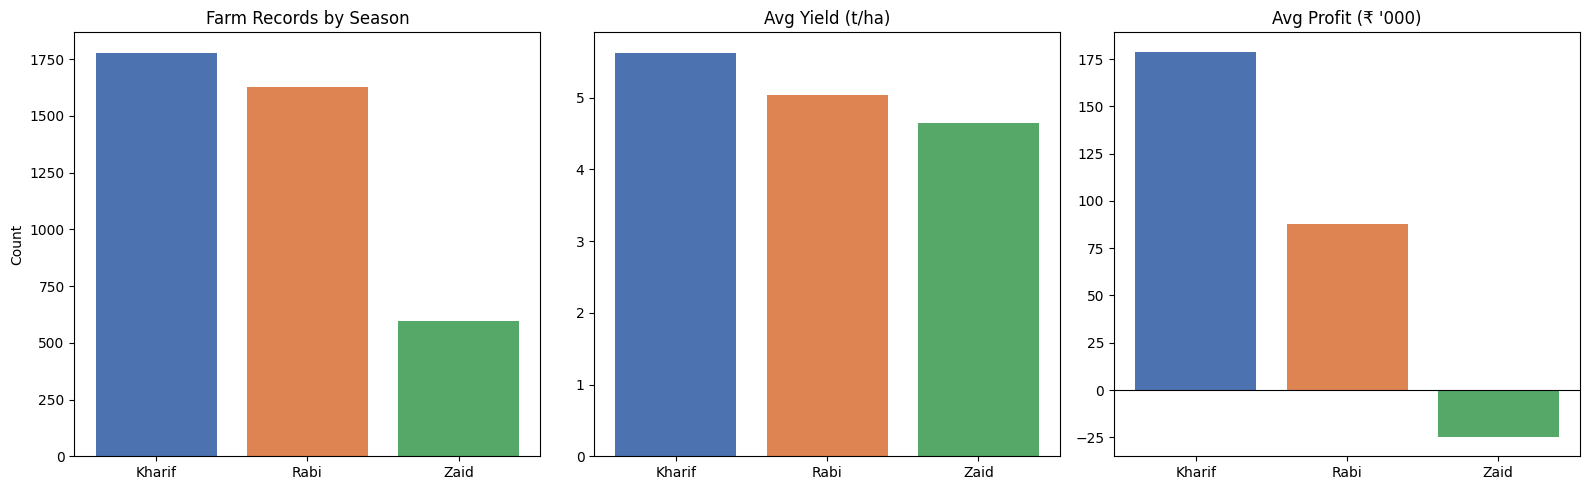

In [8]:
season_colors = {'Kharif': '#4C72B0', 'Rabi': '#DD8452', 'Zaid': '#55A868'}
colors_list = [season_colors[s] for s in season_order]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

counts = df['Season'].value_counts().reindex(season_order)
axes[0].bar(counts.index, counts.values, color=colors_list)
axes[0].set_title('Farm Records by Season')
axes[0].set_ylabel('Count')

yld = df.groupby('Season')['Yield_Tonnes_Ha'].mean().reindex(season_order)
axes[1].bar(yld.index, yld.values, color=colors_list)
axes[1].set_title('Avg Yield (t/ha)')

prof = df.groupby('Season')['Profit_INR'].mean().reindex(season_order) / 1000
axes[2].bar(prof.index, prof.values, color=colors_list)
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set_title("Avg Profit (₹ '000)")

plt.tight_layout()
plt.show()

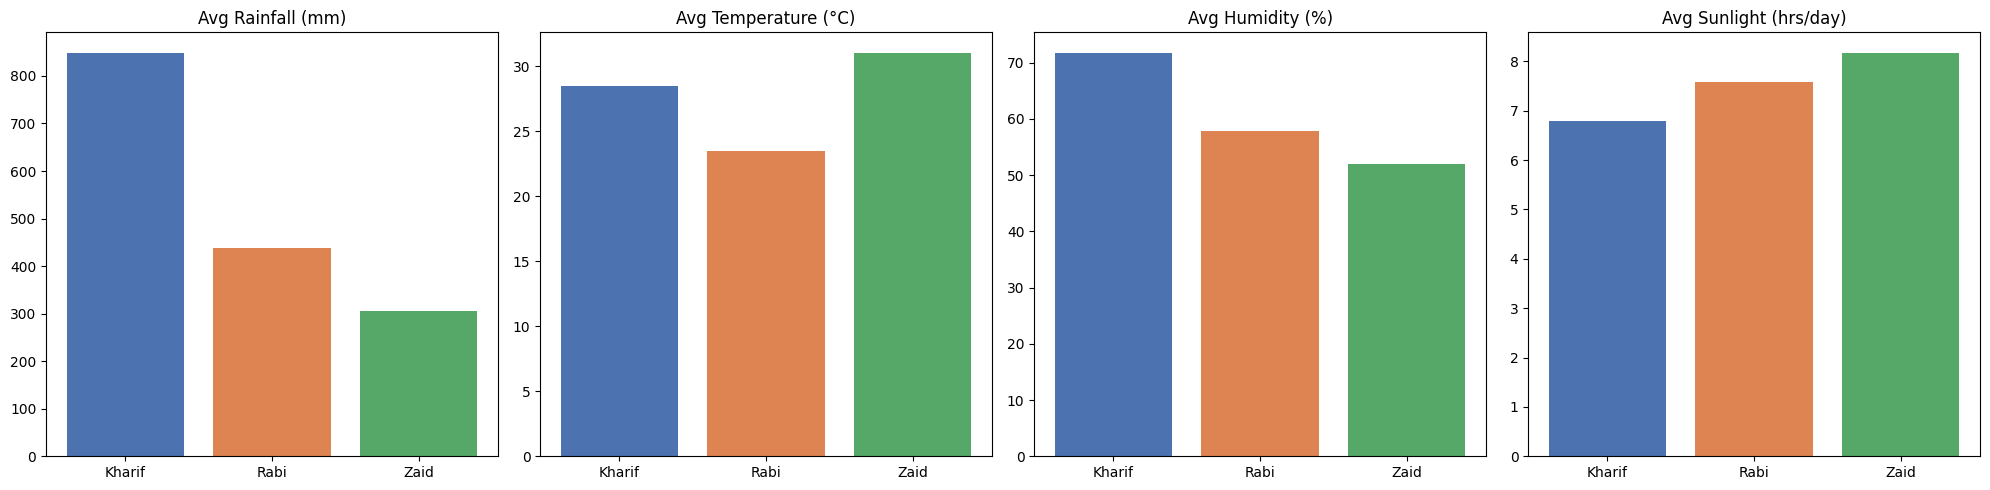

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

metrics = [
    ('Rainfall_mm', 'Avg Rainfall (mm)'),
    ('Avg_Temperature_C', 'Avg Temperature (°C)'),
    ('Humidity_pct', 'Avg Humidity (%)'),
    ('Sunlight_Hours_Day', 'Avg Sunlight (hrs/day)'),
]

for ax, (col, title) in zip(axes, metrics):
    vals = df.groupby('Season')[col].mean().reindex(season_order)
    ax.bar(vals.index, vals.values, color=colors_list)
    ax.set_title(title)

plt.tight_layout()
plt.show()

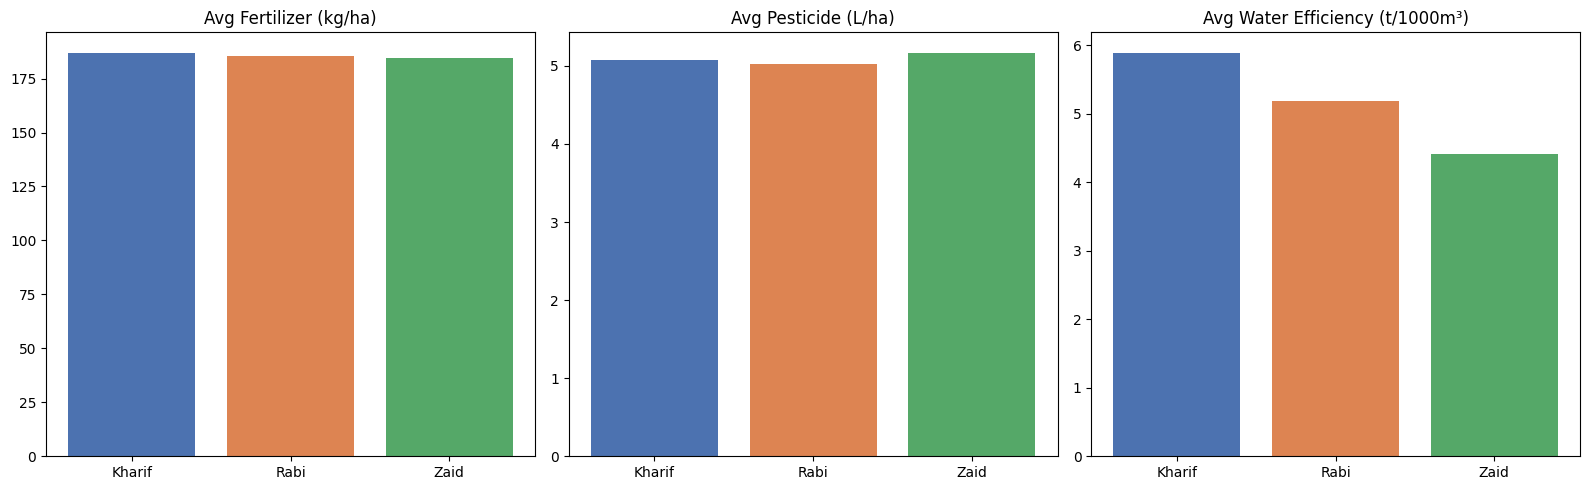

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

fert = df.groupby('Season')['Fertilizer_kg_ha'].mean().reindex(season_order)
axes[0].bar(fert.index, fert.values, color=colors_list)
axes[0].set_title('Avg Fertilizer (kg/ha)')

pest = df.groupby('Season')['Pesticide_Litre_ha'].mean().reindex(season_order)
axes[1].bar(pest.index, pest.values, color=colors_list)
axes[1].set_title('Avg Pesticide (L/ha)')

we = df.groupby('Season')['Water_Efficiency_t_per_1000m3'].mean().reindex(season_order)
axes[2].bar(we.index, we.values, color=colors_list)
axes[2].set_title('Avg Water Efficiency (t/1000m³)')

plt.tight_layout()
plt.show()

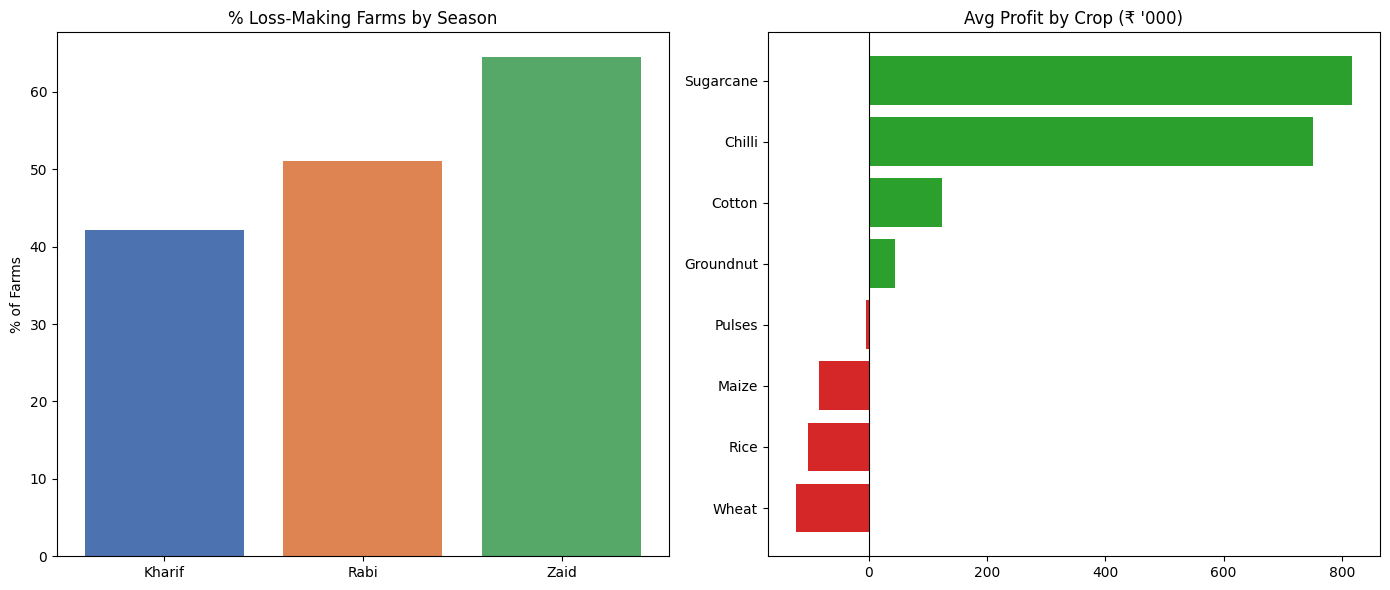

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].bar(loss_by_season.index, loss_by_season.values, color=colors_list)
axes[0].set_title('% Loss-Making Farms by Season')
axes[0].set_ylabel('% of Farms')

crop_profit_k = profit_by_crop / 1000
bar_colors = ['#2ca02c' if v >= 0 else '#d62728' for v in crop_profit_k.values]
axes[1].barh(crop_profit_k.index[::-1], crop_profit_k.values[::-1], color=bar_colors[::-1])
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title("Avg Profit by Crop (₹ '000)")

plt.tight_layout()
plt.show()

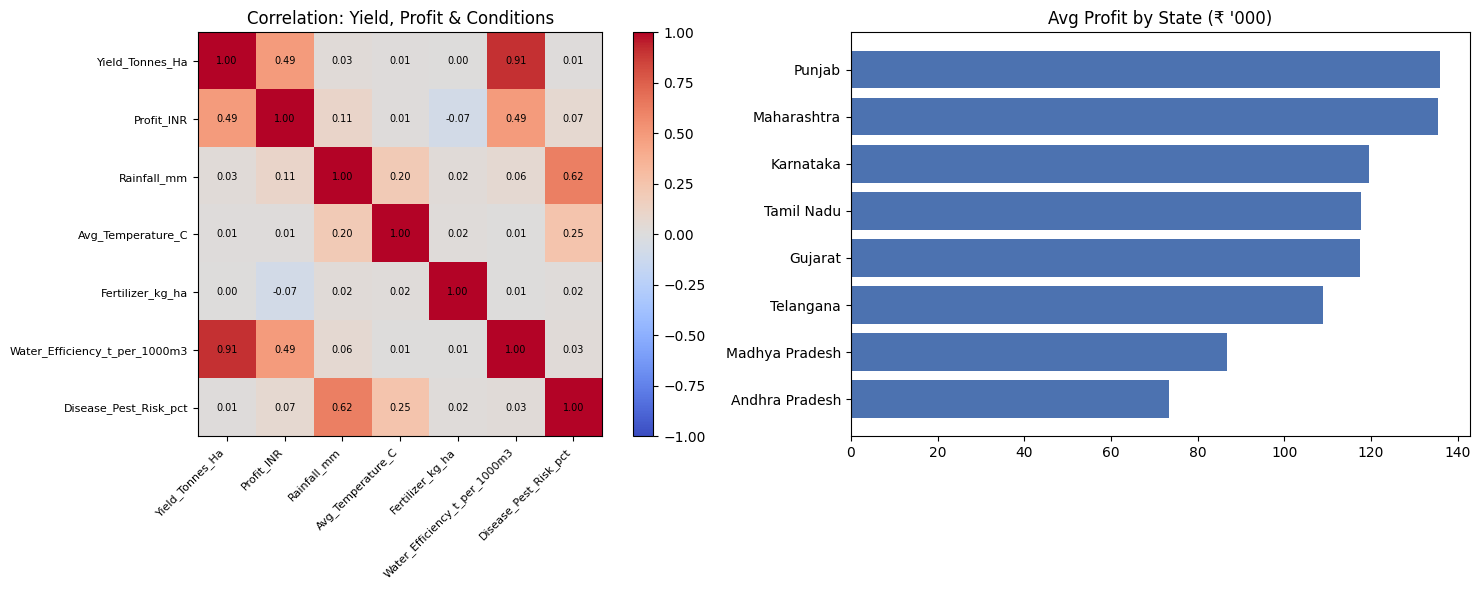

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

im = axes[0].imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
axes[0].set_xticks(range(len(corr.columns)))
axes[0].set_xticklabels(corr.columns, rotation=45, ha='right', fontsize=8)
axes[0].set_yticks(range(len(corr.columns)))
axes[0].set_yticklabels(corr.columns, fontsize=8)
for i in range(len(corr)):
    for j in range(len(corr)):
        axes[0].text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=7)
axes[0].set_title('Correlation: Yield, Profit & Conditions')
plt.colorbar(im, ax=axes[0], fraction=0.046)

state_profit_k = profit_by_state / 1000
axes[1].barh(state_profit_k.index[::-1], state_profit_k.values[::-1], color='#4C72B0')
axes[1].set_title("Avg Profit by State (₹ '000)")

plt.tight_layout()
plt.show()

In [13]:
print("="*60)
print("KEY INSIGHTS")
print("="*60)
print(f"1. Kharif has the most records ({counts['Kharif']}) and highest avg yield "
      f"({yld['Kharif']:.1f} t/ha) & profit (₹{prof['Kharif']:.0f}K)")
print(f"2. Zaid season averages a LOSS (₹{prof['Zaid']:.0f}K) with the highest "
      f"loss-farm rate ({loss_by_season['Zaid']:.0f}%)")
print(f"3. Overall, {overall_loss_pct:.0f}% of all farms operate at a loss")
print(f"4. Most profitable crop: {profit_by_crop.index[0]} "
      f"(₹{profit_by_crop.iloc[0]/1000:.0f}K avg profit)")
print(f"5. Least profitable crop: {profit_by_crop.index[-1]} "
      f"(₹{profit_by_crop.iloc[-1]/1000:.0f}K avg profit)")
print(f"6. Water efficiency correlates most strongly with yield (r={corr.loc['Yield_Tonnes_Ha','Water_Efficiency_t_per_1000m3']:.2f}) "
      f"and profit (r={corr.loc['Profit_INR','Water_Efficiency_t_per_1000m3']:.2f})")
print(f"7. Most profitable state: {profit_by_state.index[0]}")

KEY INSIGHTS
1. Kharif has the most records (1779) and highest avg yield (5.6 t/ha) & profit (₹179K)
2. Zaid season averages a LOSS (₹-25K) with the highest loss-farm rate (64%)
3. Overall, 49% of all farms operate at a loss
4. Most profitable crop: Sugarcane (₹817K avg profit)
5. Least profitable crop: Wheat (₹-123K avg profit)
6. Water efficiency correlates most strongly with yield (r=0.91) and profit (r=0.49)
7. Most profitable state: Punjab
